### Integrals with Taylor expansions

Any definite and proper integral can be discretized as shown:

$$
    \int_{a}^{b} \, f(x) \, dx = \sum_{k = 0}^{N - 1} \, \int_{x_k}^{x_k + h} \, f(x) \, dx
$$

With $x_0 = a$, $x_N = b$ and $h = \frac{b - a}{N}$.

Trick: expand the function $f(x)$ in a Taylor series about the point $x_k + \frac{h}{2}$:

$$
    f(x) \approx f\left(x_k + \frac{h}{2}\right) + f'\left(x_k + \frac{h}{2}\right) \left(x - x_k - \frac{h}{2}\right) + \frac{1}{2} \, f''\left(x_k + \frac{h}{2}\right) \left(x - x_k - \frac{h}{2}\right)^2 + \dots
$$

By substituting into $\int_{x_k}^{x_k + h} \, f(x) \, dx$, we can write:

$$
    \int_{a}^{b} \, f(x) \, dx \approx h \, \sum_{k = 0}^{N - 1} \, f \left( x_k + \frac{h}{2} \right)
$$

The error bound is:

$$
    \frac{h^3}{24} \, N \, \max_{x \in [a, b]}(\left| f''(x) \right| )
$$

Let's apply this formula to:

$$
    \int_{0}^{2 \pi} \, e^{- x} \, \cos(x) \, dx
$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
f = lambda x: np.exp(- x) * np.cos(x) # Function
f1 = lambda x: - np.exp(- x ) * (np.cos(x) + np.sin(x)) # First derivative
f2 = lambda x: 2 * np.exp(- x) * np.sin(x) # Second derivative
f4 = lambda x: - 4 * f(x) # Fourth derivative

Let's check the inherent error. If $x$ carries an error $\delta x$ (very small, but not zero), functions $f(x)$ propagates them, carrying and error $\delta f$:

$$
    \frac{\delta f}{\delta x} = \left| f'(x) \right|
$$

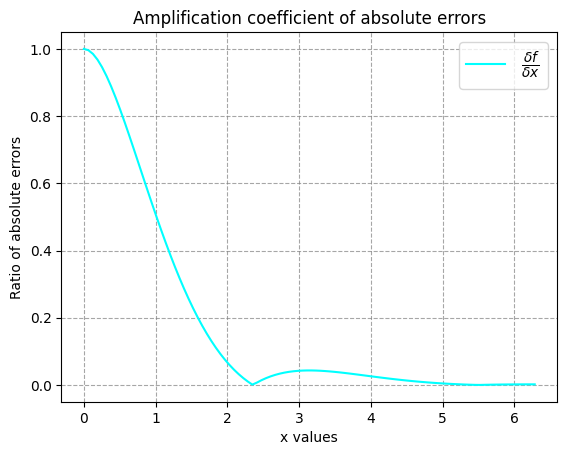

In [3]:
a, b = 0.0, 2.0 * np.pi # a = 0, b = 2 * pi
x = np.linspace(a, b, 100)

plt.plot(x, np.abs(f1(x)), label = r'$\frac{\delta f}{\delta x}$', color = 'cyan')
plt.title('Amplification coefficient of absolute errors', fontsize = 12)
plt.xlabel('x values')
plt.ylabel('Ratio of absolute errors')
plt.grid(True, linestyle = '--', color = 'gray', alpha = 0.7)
plt.legend(loc = 'upper right', fontsize = 14)
plt.show()

As we can easily see, the function $f(x)$ does not amplify the error carried by $x$ for any value of $x$.

In [4]:
def integral(f, f2, f4, a, b, h, precise = False):

    ba = b - a
    N = round(ba / h)
    h = ba / N # Recalculate h to match the exact grid
    x = np.linspace(a, b, N, endpoint = False)
    midpoints = x + h / 2.0

    I = h * np.sum(f(midpoints))

    if not precise:
        err = (h ** 3 / 24.0) * N * np.max(np.abs(f2(x)))
    else:
        I += (h ** 3 / 24.0) * np.sum(f2(midpoints))
        err = (h ** 5 / 1920.0) * N * np.max(np.abs(f4(x)))

    return (I, err)

In [5]:
h = 0.01 # h = 1e-02
integral(f, f2, f4, a, b, h) # Computing the integral (h = 1e-02)

(np.float64(0.49906211550421725), np.float64(1.689737151993707e-05))

Our result:

$$
    I = 0.49906 \pm 0.00002
$$

The real value of the integral is:

$$
    \int_{0}^{2 \pi} \, e^{- x} \, \cos(x) \, dx = \frac{1}{2} \, \left( 1 - e^{- 2 \pi} \right)
$$

In [6]:
res = 0.5 * (1.0 - np.exp(- 2.0 * np.pi)) # Real value
print(f"{res:.5f}")

0.49907


Let's reduce $h$

In [7]:
h = 0.0001 # h = 1e-04
integral(f, f2, f4, a, b, h)

(np.float64(0.4990662782182594), np.float64(1.6880585457499212e-09))

New result $h = 10^{-4}$:

$$
    I = 0.499066278 \pm 0.000000002
$$

In [8]:
print(f"{res:.9f}")

0.499066279


Let's reduce $h$ again

In [9]:
h = 0.000001 # h = 1e-06
integral(f, f2, f4, a , b, h)

(np.float64(0.49906627863410435), np.float64(1.688066605645763e-13))

More precise result $h = 10^{-6}$:

$$
    I = 0.4990662786341 \pm 0.0000000000002
$$

In [10]:
print(f"{res:.13f}")

0.4990662786341


Let's try out accounting the second order term:

$$
    I = h \, \sum_{k = 0}^{N - 1} \, f \left( x_k + \frac{h}{2} \right) + \frac{h^3}{24} \, \sum_{k = 0}^{N - 1} \, f'' \left( x_k + \frac{h}{2} \right)
$$

Therefore, the error bound is given by the third term of the Taylor expansion:

$$
    \frac{h^5}{1920} \, N \, \max_{x \in [a, b]}(\left| f''''(x) \right| )
$$

In [11]:
h = 0.01 # h = 1e-02
integral(f, f2, f4, a, b, h, precise = True)

(np.float64(0.4990662786445644), np.float64(1.31165472925734e-10))

Result obtained:

$$
    I = 0.4990662786 \pm 0.0000000001
$$

In [12]:
print(f"{res:.10f}")

0.4990662786
